## Hyperparameter Tuning

Values of the chosen hyperparameters as directed in the T01 file will be chosen in this file.

We compare parameters sequentially for the original training and testing data sets on the original T01 Jupyter Notebook.

In [23]:
2+4

6

In [24]:
# If you don’t already have these installed:
!pip install pynvml pyyaml pandas

Defaulting to user installation because normal site-packages is not writeable


In [27]:
# If you don’t already have these installed:
import os, time, subprocess
import yaml
import pandas as pd

# NVIDIA Management Library
import pynvml
pynvml.nvmlInit()

def gpu_mem_info(dev=0):
    """Return (used_MB, free_MB, total_MB) on GPU dev."""
    h = pynvml.nvmlDeviceGetHandleByIndex(dev)
    m = pynvml.nvmlDeviceGetMemoryInfo(h)
    return (m.used // 2**20, m.free // 2**20, m.total // 2**20)


pynvml.nvmlInit()
_handle = pynvml.nvmlDeviceGetHandleByIndex(0)

# ------------------------------------------------------------------------------
# 1) Define gpu_sampler() to record peak & average memory & utilization
def gpu_sampler(interval=0.5):
    """
    Start a background sampler that polls GPU memory (MB) and utilization (%) every
    `interval` seconds. Returns:
      - stop_event: threading.Event to signal sampling stop
      - sampler_thread: the Thread object (daemon)
      - mem_samples: list to collect memory samples
      - util_samples: list to collect utilization samples
    """
    mem_samples = []
    util_samples = []
    stop_event = threading.Event()
    
    def _poll():
        while not stop_event.is_set():
            mi = pynvml.nvmlDeviceGetMemoryInfo(_handle)
            util = pynvml.nvmlDeviceGetUtilizationRates(_handle).gpu
            mem_samples.append(mi.used // 2**20)
            util_samples.append(util)
            time.sleep(interval)
    
    sampler_thread = threading.Thread(target=_poll, daemon=True)
    sampler_thread.start()
    return stop_event, sampler_thread, mem_samples, util_samples

from pathlib import Path

def return_rmse_from_model_log(log_path):
    last_line = None
    
    try:
        with open(log_path, 'r') as f:
            for line in f:
                if line.startswith("|    valid    |"):
                    last_line = line.rstrip("\n")
    
        # Remove all spaces
        nospace = last_line.replace(" ", "")
        # Split by '|' and filter out empty entries
        parts = [p for p in nospace.split("|") if p]
        rmse_e, rmse_f = parts[1], parts[2]
    except Exception as excep:
        print("Log parse error !")
        return None, None
    
    return float(rmse_e), float(rmse_f)

import threading
import time

def run_experiment(cfg, label):
    """
    cfg: dict of MACE config parameters
    label: a string tag (e.g. "bs=20" or "ni=3")
    """
    fname = f'config/tmp/tmp-{label}.yml'
    os.makedirs('config/tmp', exist_ok=True)
    with open(fname, 'w') as f:
        yaml.dump(cfg, f)

    # Start GPU sampler
    stop_event, sampler_thread, mem_samples, util_samples = gpu_sampler(interval=0.5)

    # Time & run training
    t0 = time.time()
    proc = subprocess.run(
        ['mace_run_train', '--config', fname],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True
    )
    elapsed = time.time() - t0

    # Stop sampling
    stop_event.set()
    sampler_thread.join()

    # Compute peak & average from samples
    mem_peak   = max(mem_samples) if mem_samples else None
    mem_avg    = sum(mem_samples)/len(mem_samples) if mem_samples else None
    util_peak  = max(util_samples) if util_samples else None
    util_avg   = sum(util_samples)/len(util_samples) if util_samples else None


    # parse RMSE
    rmse_e, rmse_f = return_rmse_from_model_log(Path(f"MACE_models/mace_N200_run-123.log"))
    
    return {
        'label': label,
        'time_s': elapsed,
        'mem_peak_MB': mem_peak,
        'mem_avg_MB': mem_avg,
        'util_peak_pct': util_peak,
        'util_avg_pct': util_avg,
        'rmse_e_meV': rmse_e,
        'rmse_f_meV_per_A': rmse_f
    }

from matplotlib import pyplot as plt

def create_plots(results, super_title, x_title, hyper_param, label_tag):
    """
        hyper_param is the actual name in the config file
        label_tag : bs, ni....
    """
    df = pd.DataFrame(results)
    
    df[hyper_param] = df['label'].str.extract(label_tag).astype(int)

    
    # Assuming `df` is already loaded with your sweep results
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1) Training time vs Batch Size
    axes[0].plot(df[hyper_param], df['time_s'], marker='o')
    axes[0].set_xlabel(x_title)
    axes[0].set_ylabel('Training Time (s)')
    axes[0].set_title(f'Time vs {x_title}')
    
    # 2) GPU Memory (Peak & Average) vs Batch Size
    axes[1].plot(df[hyper_param], df['mem_peak_MB'], marker='o')
    axes[1].plot(df[hyper_param], df['mem_avg_MB'], marker='o')
    axes[1].set_xlabel(x_title)
    axes[1].set_ylabel('Memory (MB)')
    axes[1].set_title(f'GPU Memory vs {x_title}')
    axes[1].legend(['Peak', 'Average'])
    
    # 3) Energy & Force RMSE vs Batch Size
    axes[2].plot(df[hyper_param], df['rmse_e_meV'], marker='o')
    axes[2].plot(df[hyper_param], df['rmse_f_meV_per_A'], marker='o')
    axes[2].set_xlabel(x_title)
    axes[2].set_ylabel('RMSE')
    axes[2].set_title(f'RMSE vs {x_title}')
    axes[2].legend(['Energy', 'Force'])
    
    # Main title for all subplots
    fig.suptitle(f'Training Performance : {super_title}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



In [28]:
with open('config/config-02.yml') as f:
    base_cfg = yaml.safe_load(f)

base_cfg

{'model': 'MACE',
 'num_interactions': 2,
 'num_channels': 32,
 'max_L': 0,
 'correlation': 2,
 'r_max': 4.0,
 'max_ell': 2,
 'name': 'mace_N200',
 'model_dir': 'MACE_models',
 'log_dir': 'MACE_models',
 'checkpoints_dir': 'MACE_models',
 'results_dir': 'MACE_models',
 'train_file': 'data/solvent_xtb_train_200.xyz',
 'valid_fraction': 0.1,
 'test_file': 'data/solvent_xtb_test.xyz',
 'E0s': 'average',
 'energy_key': 'energy_xtb',
 'forces_key': 'forces_xtb',
 'device': 'cuda',
 'batch_size': 20,
 'max_num_epochs': 20,
 'swa': True,
 'seed': 123}

In [29]:
# Sweep and collect
results = []
for bs in [10, 20, 30, 40, 50]:
    cfg = dict(base_cfg, batch_size=bs)

    # run, add results to dict, run again
    print(f"training started: {cfg['name']}, batch_size: {bs}")
    results.append(run_experiment(cfg, f'bs={bs}'))
    print(f"training finished: {cfg['name']}, batch_size: {bs}")

df = pd.DataFrame(results)
df.round(3)
df

training started: mace_N200, batch_size: 10
training finished: mace_N200, batch_size: 10
training started: mace_N200, batch_size: 20
training finished: mace_N200, batch_size: 20
training started: mace_N200, batch_size: 30
training finished: mace_N200, batch_size: 30
training started: mace_N200, batch_size: 40
training finished: mace_N200, batch_size: 40
training started: mace_N200, batch_size: 50
training finished: mace_N200, batch_size: 50


,label,time_s,mem_peak_MB,mem_avg_MB,util_peak_pct,util_avg_pct,rmse_e_meV,rmse_f_meV_per_A
0,bs=10,39.934205,793,719.775000,31,18.375000,429.9,1110.9
1,bs=20,37.854965,937,724.934211,56,18.473684,380.2,912.2
2,bs=30,32.981385,1107,796.651515,62,21.106061,1697.5,1976.9
3,bs=40,25.499953,1397,922.725490,75,23.764706,3786.2,1011.5
4,bs=50,27.675176,1519,917.375000,75,18.625000,4454.8,877.0


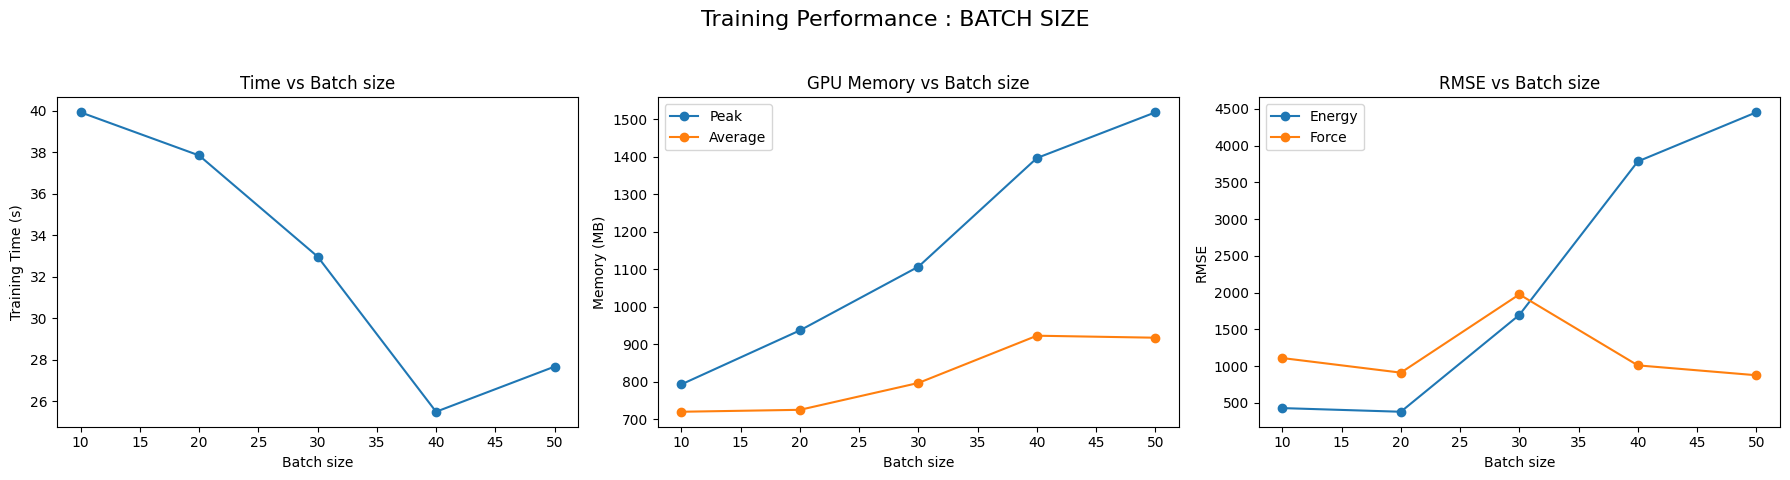

In [30]:
create_plots(
    results,
    super_title="BATCH SIZE",
    x_title="Batch size",
    hyper_param="batch_size",
    label_tag = r'bs=(\d+)'
)

training started: mace_N200, num_interactions: 1
training finished: mace_N200, num_interactions: 1
training started: mace_N200, num_interactions: 2
training finished: mace_N200, num_interactions: 2
training started: mace_N200, num_interactions: 3
training finished: mace_N200, num_interactions: 3


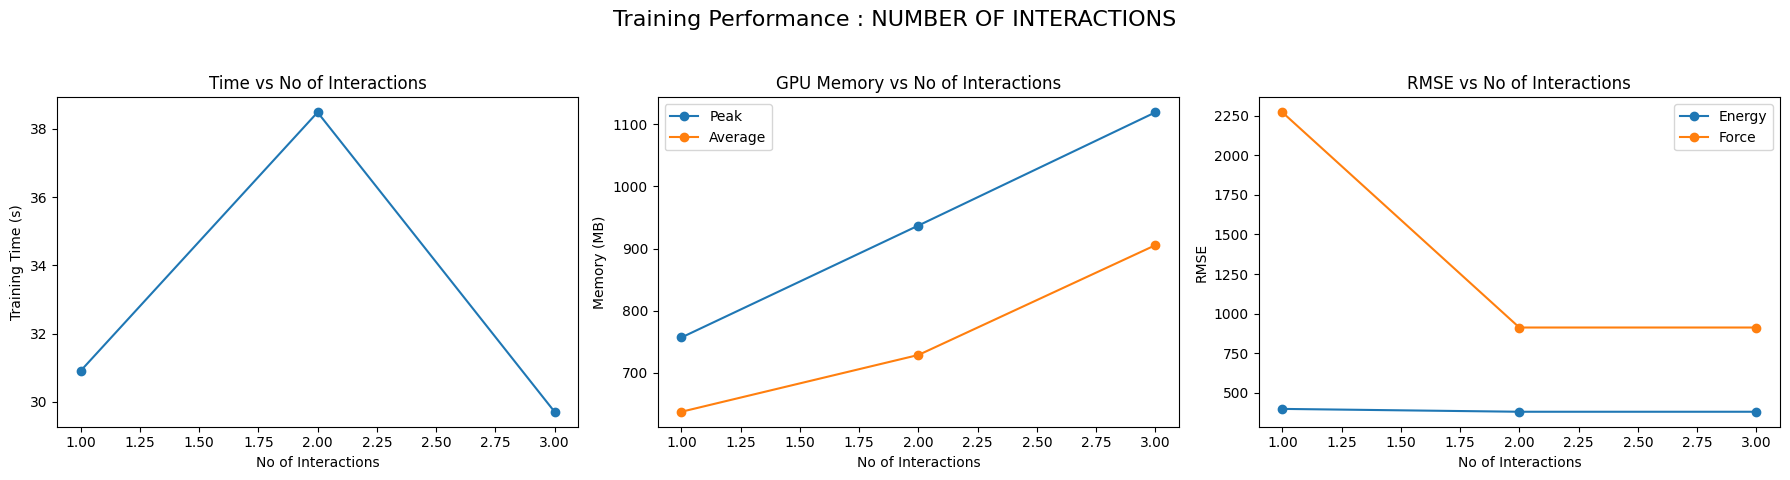

,label,time_s,mem_peak_MB,mem_avg_MB,util_peak_pct,util_avg_pct,rmse_e_meV,rmse_f_meV_per_A
0,ni=1,30.903438,757,637.548387,46,13.580645,398.2,2271.4
1,ni=2,38.482531,937,728.870130,43,17.220779,380.2,912.2
2,ni=3,29.706924,1119,905.400000,54,25.633333,380.2,912.2


In [31]:
# 5.2 model‐size sweep (vary one hyperparameter at a time)
results = []
for ni in [1, 2, 3]:
    cfg = dict(base_cfg, num_interactions=ni)
    
     # run, add results to dict, run again
    print(f"training started: {cfg['name']}, num_interactions: {ni}")
    results.append(run_experiment(cfg, f'ni={ni}'))
    print(f"training finished: {cfg['name']}, num_interactions: {ni}")

create_plots(
    results,
    super_title="NUMBER OF INTERACTIONS",
    x_title="No of Interactions",
    hyper_param="num_interactions",
    label_tag=r'ni=(\d+)'
)

df = pd.DataFrame(results)
df.round(3)
df

training started: mace_N200, num_channels: 16
training finished: mace_N200, num_channels: 16
training started: mace_N200, num_channels: 32
training finished: mace_N200, num_channels: 32
training started: mace_N200, num_channels: 64
training finished: mace_N200, num_channels: 64
training started: mace_N200, num_channels: 128
training finished: mace_N200, num_channels: 128


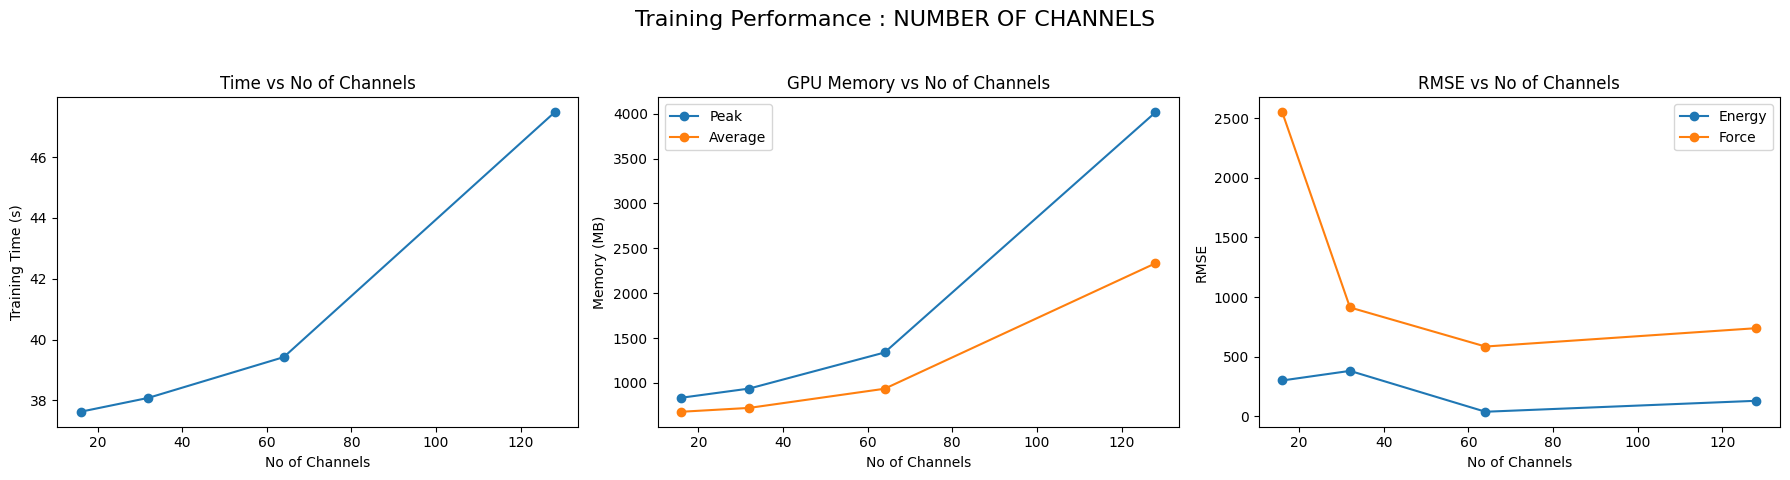

,label,time_s,mem_peak_MB,mem_avg_MB,util_peak_pct,util_avg_pct,rmse_e_meV,rmse_f_meV_per_A
0,nc=16,37.624680,835,678.750000,41,15.434211,299.6,2549.7
1,nc=32,38.080846,937,721.571429,46,18.857143,380.2,912.2
2,nc=64,39.420951,1339,935.037975,77,28.911392,37.2,584.4
3,nc=128,47.469923,4015,2332.915789,91,49.621053,129.2,738.4


In [20]:
# 5.2 model‐size sweep (vary one hyperparameter at a time)
results = []
for nc in [16, 32, 64, 128]:
    cfg = dict(base_cfg, num_channels=nc)
    
     # run, add results to dict, run again
    print(f"training started: {cfg['name']}, num_channels: {nc}")
    results.append(run_experiment(cfg, f'nc={nc}'))
    print(f"training finished: {cfg['name']}, num_channels: {nc}")


create_plots(
    results,
    super_title="NUMBER OF CHANNELS",
    x_title="No of Channels",
    hyper_param="num_channels",
    label_tag=r'nc=(\d+)'
)

df = pd.DataFrame(results)
df.round(3)
df

training started: mace_N200, max_L: 0
training finished: mace_N200, max_L: 0
training started: mace_N200, max_L: 1
training finished: mace_N200, max_L: 1
training started: mace_N200, max_L: 2
training finished: mace_N200, max_L: 2
training started: mace_N200, max_L: 3
training finished: mace_N200, max_L: 3


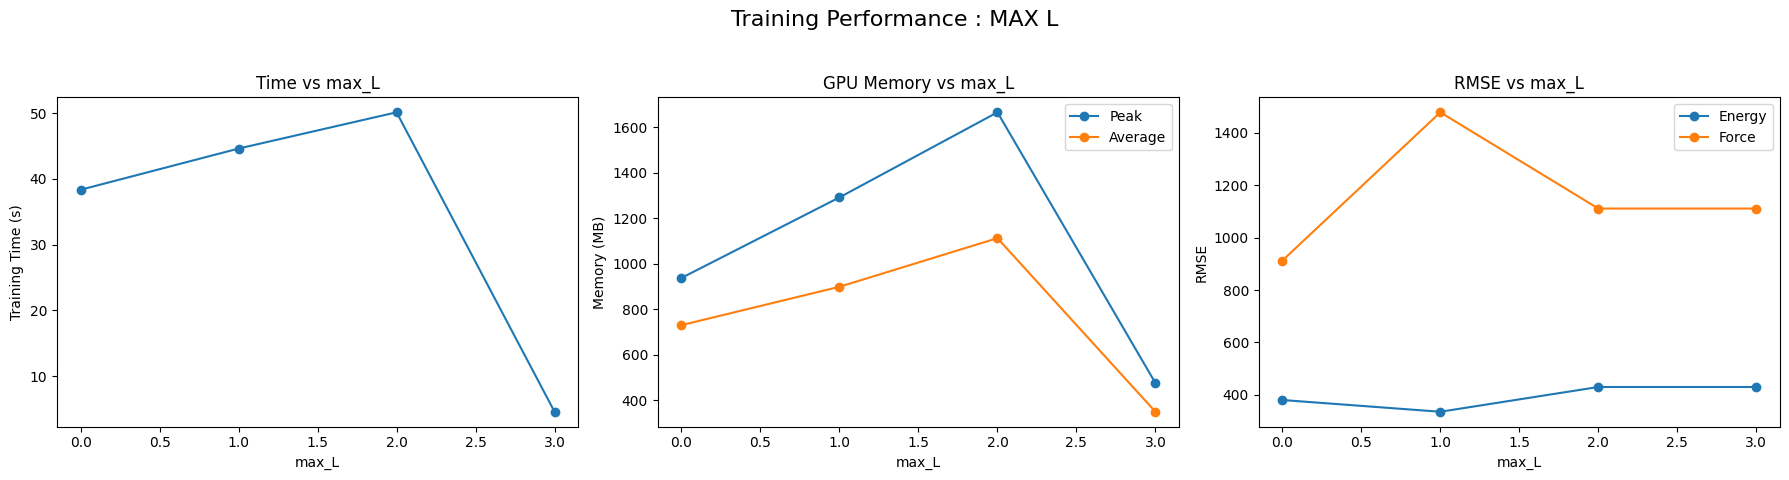

,label,time_s,mem_peak_MB,mem_avg_MB,util_peak_pct,util_avg_pct,rmse_e_meV,rmse_f_meV_per_A
0,max_L=0,38.350892,937,729.519481,42,17.519481,380.2,912.2
1,max_L=1,44.622866,1291,898.111111,70,31.111111,335.4,1478.2
2,max_L=2,50.140455,1665,1111.821782,88,45.316832,429.9,1110.9
3,max_L=3,4.569320,475,348.800000,4,0.400000,429.9,1110.9


In [21]:
results = []
for L in [0, 1, 2, 3]:
    cfg = dict(base_cfg, max_L=L)
    
     # run, add results to dict, run again
    print(f"training started: {cfg['name']}, max_L: {L}")
    results.append(run_experiment(cfg, f'max_L={L}'))
    print(f"training finished: {cfg['name']}, max_L: {L}")


create_plots(
    results,
    super_title="MAX L",
    x_title="max_L",
    hyper_param="max_L",
    label_tag=r'L=(\d+)'
)


df = pd.DataFrame(results)
df.round(3)
df

training started: mace_N200, correlation: 1
training finished: mace_N200, correlation: 1
training started: mace_N200, correlation: 2
training finished: mace_N200, correlation: 2
training started: mace_N200, correlation: 3
training finished: mace_N200, correlation: 3
training started: mace_N200, correlation: 4
training finished: mace_N200, correlation: 4
training started: mace_N200, correlation: 5
training finished: mace_N200, correlation: 5


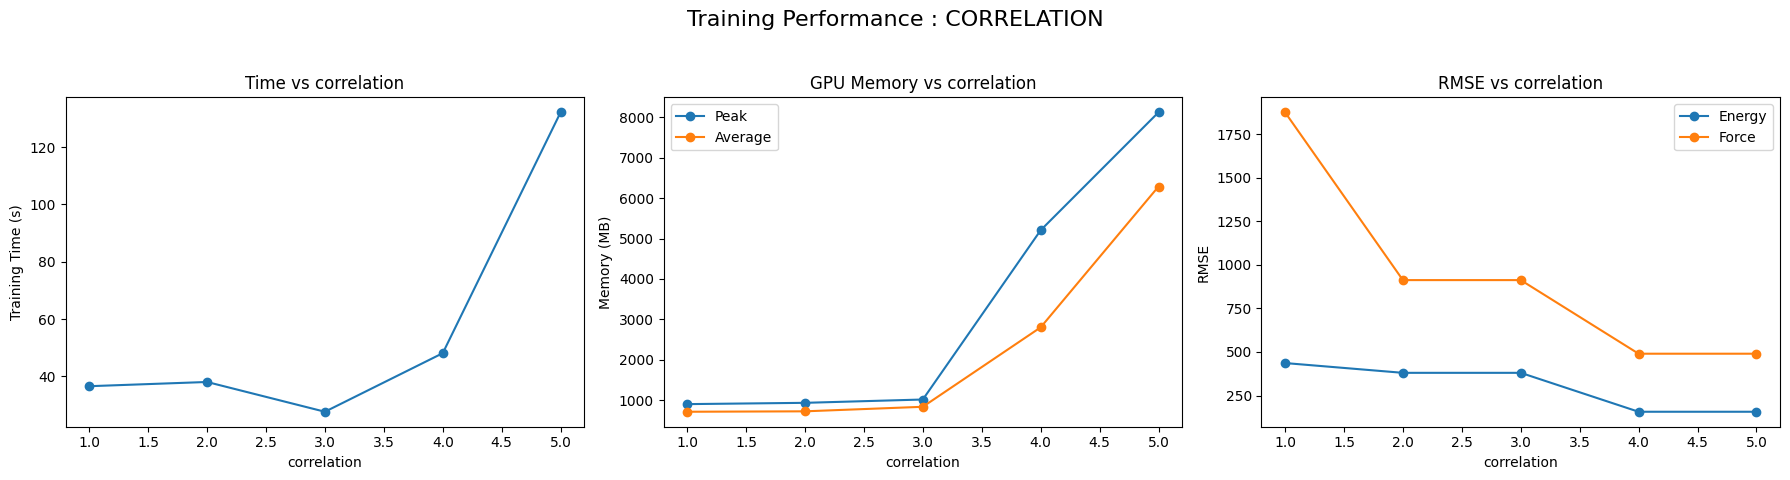

,label,time_s,mem_peak_MB,mem_avg_MB,util_peak_pct,util_avg_pct,rmse_e_meV,rmse_f_meV_per_A
0,correlation=1,36.547044,905,716.424658,46,18.260274,436.3,1874.9
1,correlation=2,38.020662,937,726.881579,47,17.907895,380.2,912.2
2,correlation=3,27.624828,1019,839.035714,57,24.732143,380.2,912.2
3,correlation=4,48.079961,5205,2803.639175,89,45.164948,156.9,489.9
4,correlation=5,132.194611,8121,6285.439394,100,60.151515,156.9,489.9


In [32]:
results = []
for corr in [1,2, 3,4,5]:
    cfg = dict(base_cfg, correlation=corr)
    
     # run, add results to dict, run again
    print(f"training started: {cfg['name']}, correlation: {corr}")
    results.append(run_experiment(cfg, f'correlation={corr}'))
    print(f"training finished: {cfg['name']}, correlation: {corr}")


create_plots(
    results,
    super_title="CORRELATION",
    x_title="correlation",
    hyper_param="correlation",
    label_tag=r'correlation=(\d+)'
)

df = pd.DataFrame(results)
df.round(3)
df

We note that above variations give us an excellent idea of points of right balance when we hit the margin of dimininshing returns :
- batch size: 10 or 20
- no of interactions: 2 or 3 (3 as time gets lower)
- no of channels: 64 (rmse increase with 128)
- max L: 0 or 2 (error lower for these, why difference ??)
- correlation: 3 or 5 (why is 4 so high ?)


training started: mace_N200, r_max: 1
training finished: mace_N200, r_max: 1
training started: mace_N200, r_max: 2
training finished: mace_N200, r_max: 2
training started: mace_N200, r_max: 3
training finished: mace_N200, r_max: 3
training started: mace_N200, r_max: 4
training finished: mace_N200, r_max: 4
training started: mace_N200, r_max: 5
training finished: mace_N200, r_max: 5


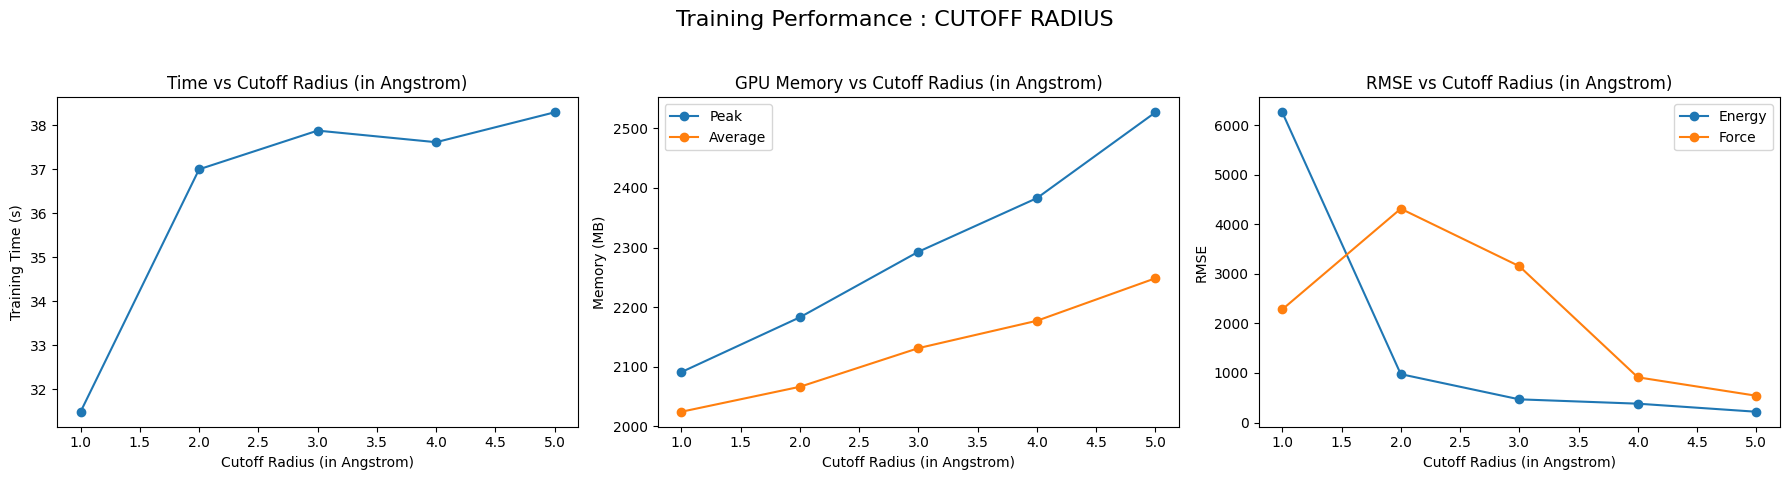

In [15]:
# 5.2 model‐size sweep (vary one hyperparameter at a time)
results = []
for r in [1, 2, 3, 4, 5]:
    cfg = dict(base_cfg, r_max=r)
    
     # run, add results to dict, run again
    print(f"training started: {cfg['name']}, r_max: {r}")
    results.append(run_experiment(cfg, f'r={r}'))
    print(f"training finished: {cfg['name']}, r_max: {r}")


create_plots(
    results,
    super_title="CUTOFF RADIUS",
    x_title="Cutoff Radius (in Angstrom)",
    hyper_param="r_max",
    label_tag=r'r=(\d+)'
)

In [14]:
cfg, base_cfg
# note that since we only change one specific property inside the basecfg each time, nothing else is affected

({'model': 'MACE',
  'num_interactions': 2,
  'num_channels': 32,
  'max_L': 0,
  'correlation': 5,
  'r_max': 4.0,
  'max_ell': 2,
  'name': 'mace_N200',
  'model_dir': 'MACE_models',
  'log_dir': 'MACE_models',
  'checkpoints_dir': 'MACE_models',
  'results_dir': 'MACE_models',
  'train_file': 'data/solvent_xtb_train_200.xyz',
  'valid_fraction': 0.1,
  'test_file': 'data/solvent_xtb_test.xyz',
  'E0s': 'average',
  'energy_key': 'energy_xtb',
  'forces_key': 'forces_xtb',
  'device': 'cuda',
  'batch_size': 20,
  'max_num_epochs': 20,
  'swa': True,
  'seed': 123},
 {'model': 'MACE',
  'num_interactions': 2,
  'num_channels': 32,
  'max_L': 0,
  'correlation': 2,
  'r_max': 4.0,
  'max_ell': 2,
  'name': 'mace_N200',
  'model_dir': 'MACE_models',
  'log_dir': 'MACE_models',
  'checkpoints_dir': 'MACE_models',
  'results_dir': 'MACE_models',
  'train_file': 'data/solvent_xtb_train_200.xyz',
  'valid_fraction': 0.1,
  'test_file': 'data/solvent_xtb_test.xyz',
  'E0s': 'average',
  'en